## Group-level Analysis
The move to group-level analysis is conceptually a shift from **Signal-to-Noise Ratio (SNR)** to **Effect-to-Variance Ratio**. Up until now, we have studied the responses of individual brain. We’ve cleaned artifacts from specific subjects, averaged their trials, and interpreted the prominence of a P300 ERP or a Alpha desynchronization in a single person's data. That is a vital skill — but in the process of producing scientific results and insights, an individual is an anecdote. Group analysis is where we turn those stories into evidence.

If you look at the raw EEG of twenty different people, you’ll see twenty different "baselines." One person might have a naturally thick skull that dampens every signal; another might have been slightly more caffeinated, leading to higher resting beta power.

If we only looked at individuals, we would be overwhelmed by the "biological noise" of human diversity. Group analysis allows us to look through the individual and find the canonical human response. We are searching for the signal that survives the "noise" of being a unique human being.

### Analysis structures
When we move to the group level, our "Independent Variables" usually fall into two possible buckets:
#### A. Experimental Conditions (Within-Subject Factors)

This is the "What." We are asking: How does the brain change its response when the task changes?

Example: Does the brain process a "Wrong" mathematical equation differently than a "Right" one?

The Logic: Every subject does both tasks. We are looking for a consistent shift within the same brain.

#### B. Subject Cohorts (Between-Subject Factors)

This is the "Who." We are asking: How do different types of brains respond to the same task?

Example: Do professional musicians show faster auditory processing than non-musicians? Do patients with ADHD show different frontal theta power than neurotypical controls?

The Logic: You can’t be both a "Patient" and a "Control." Here, we are looking for a consistent difference between two distinct populations.

### Imports & Helper Functions

In [1]:
import mne, re, matplotlib.pyplot as plt, numpy as np, pandas as pd
from glob import glob as ls
mne.set_log_level('CRITICAL')
ch_names = []

def trans_to_zscore(inst,bsl=(-.2,0)):
    # normalize evoked with z-score
    bsl_mask = (inst.times >= bsl[0]) & (inst.times <= bsl[1])
    return inst.copy().apply_function(lambda y: (y-np.mean(y[bsl_mask]))/np.std(y[bsl_mask]))

def tfr_to_evk(tfr,f_lim):
    # compute power per frequency band
    power = tfr.copy().crop(fmin=f_lim[0], fmax=f_lim[1])
    return mne.EvokedArray(power.data.mean(axis=1), tfr.info, tfr.times[0])

### Event-related Potentials

In [2]:
conditions = ["Size==1 & Correct==1","Size==4 & Correct==1"]

In [6]:
fmin=None; fmax = 20
timelocks = {
    "stim":(-.2,1.),
    "prob":(-.2,1.),
    "fdb":(-.2,1.),
    "resp":(-1.2,.2),
}

In [7]:
files = {lck:[f for f in sorted(ls(f"Data/*/*{lck}-epo.fif.gz"))] for lck in timelocks.keys()};

In [11]:
evoked = {c:[] for c in conditions}
lck = "fdb"
for f in files[lck]:
    print(f"Loading {f}...")
    epoch = mne.read_epochs(f,preload=True)
    epoch.info['bads'] = [];
    ch_names = epoch.ch_names
    for c in conditions:
        evoked[c].extend([epoch[c].average().apply_baseline(timelocks[lck])]);

Loading Data/DMSS/dmss01_fdb-epo.fif.gz...
Loading Data/DMSS/dmss03_fdb-epo.fif.gz...
Loading Data/DMSS/dmss06_fdb-epo.fif.gz...
Loading Data/DMSS/dmss07_fdb-epo.fif.gz...
Loading Data/DMSS/dmss08_fdb-epo.fif.gz...
Loading Data/DMSS/dmss11_fdb-epo.fif.gz...
Loading Data/DMSS/dmss14_fdb-epo.fif.gz...
Loading Data/DMSS/dmss15_fdb-epo.fif.gz...
Loading Data/DMSS/dmss16_fdb-epo.fif.gz...
Loading Data/DMSS/dmss19_fdb-epo.fif.gz...
Loading Data/DMSS/dmss20_fdb-epo.fif.gz...
Loading Data/DMSS/dmss21_fdb-epo.fif.gz...
Loading Data/DMSS/dmss23_fdb-epo.fif.gz...
Loading Data/DMSS/dmss25_fdb-epo.fif.gz...
Loading Data/DMSS/dmss28_fdb-epo.fif.gz...
Loading Data/DMSS/dmss30_fdb-epo.fif.gz...


We are now ready to explore the differences between conditions. We start out by computing and plotting the differences **for each channel individually**.

First, we select two conditions to compare and a time interval of interest. Next, the code below will calculate "c1 minus c2" and plot the difference. Positive values mean higher evoked potentials for condition c1 and negative values mean higher potentials for condition c2.

Due to variations in subject anatomy, recording equipment, EEG cap setup, etc. the numerical scale of our recordings can vary significantly. This may result in outlier subjects that effect disproportionate impact on the group mean. One way to compensate for this is relying on statistical Z-Score as the normalization method, rather than simple baselining by subtracting the mean. Our sample data set appears to be unaffected by outlier subjects, but you may find them in your own recordings.

In our example data set we observe a sustained difference between conditions from 150ms onward in the parietal (red and purple) channels, while other channels show greater variation (central - light blue and pink) or no difference (frontal - green and yellow).

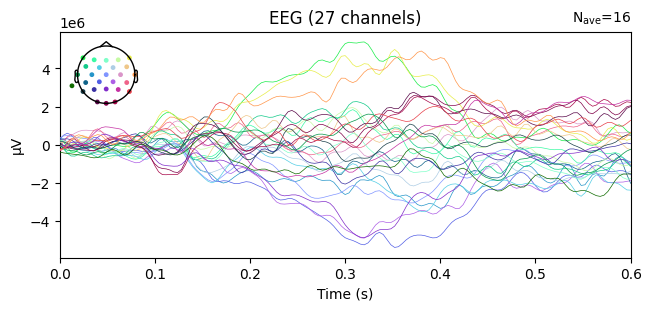

In [14]:
c1 = conditions[0]; c2 = conditions[1]

evokeds_cond = {c:[trans_to_zscore(subj).crop(0,.6) for subj in subjs] for c,subjs in evoked.items()}
difference_evks = [mne.combine_evoked([a,b],[1,-1]) for a,b in zip(evokeds_cond[c1],evokeds_cond[c2])]
grand_diff = mne.grand_average(difference_evks).crop(0,.6)

grand_diff.plot();

Based on our observations in the previous step or hypotheses drawn from literature, we may choose to gather a signal with strong SNR by **averaging over a number of channels**. You will likely change the ROI based on your hypothesis, or in a exploratory fashion - searching for regions where your experimental conditions yield noticable differences in the ERP. You can use the green electrodes in the reference at the bottom of the notebook to find out the names of electrodes in your ROI.

In the next plot we baseline and compare the ERPs for our conditions of interest. The scalp diagram visualizes the ROI we selected. The figure is calculated over ERPs of a number of subjects and the shaded areas indicate the 95% confidence intervals.

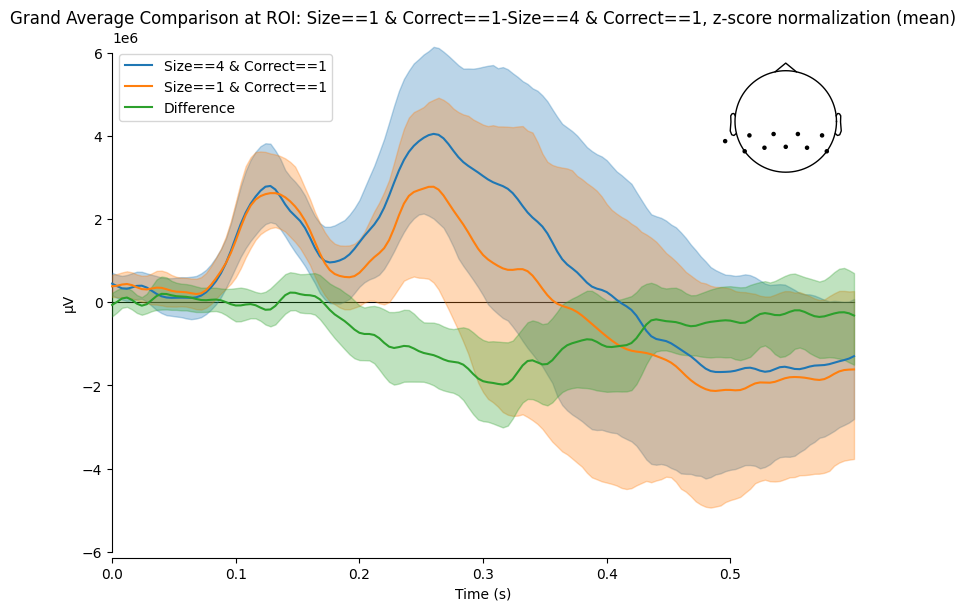

In [16]:
# Pick two conditions to compare
c1 = conditions[0]; c2 = conditions[1]

# Comparing conditions at a specific ROI (e.g., Parietal electrodes)
roi = ['PO3']; roi = None
roi = [ch for ch in ch_names if 'P' in ch]

# Choose time interval to plot in figure
crop_time = (0,1.)
crop_time = timelocks["fdb"]

#evokeds_cond = {c:[subj[c].copy().apply_baseline(bsl).crop(0,.6) for subj in evoked.values()] for c in conditions}
evokeds_cond = {c:[trans_to_zscore(subj).crop(0,.6) for subj in subjs] for c,subjs in evoked.items()}
difference_evks = [mne.combine_evoked([a,b],[1,-1]) for a,b in zip(evokeds_cond[c1],evokeds_cond[c2])]

mne.viz.plot_compare_evokeds(
    {c2: evokeds_cond[c2], c1: evokeds_cond[c1], 'Difference': difference_evks},
    picks=roi,
    combine='mean',
    title=f'Grand Average Comparison at ROI: {c1}-{c2}, z-score normalization',
    show_sensors=True
);

## Time-frequency Analysis
In group analysis, TFR presents a unique challenge: the "1/f Power Law." Low frequencies (Delta/Theta) naturally have much higher raw power than high frequencies (Gamma). Without proper normalization, your group statistics would only ever show you the low-frequency effects.

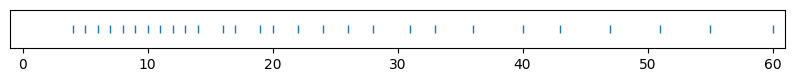

In [31]:
# below freqs is defined as a logarithmic space on 1-60Hz, projected to integers, then 1Hz and 2Hz are dropped
freqs = np.unique(np.round(np.exp(np.linspace(0,np.log(60)))))[3:]
# we want to separate analysis by conditions - which are defined as strings that can operate on the Epochs object
conditions = ["Size==1 & Correct==1","Size==4 & Correct==1"]#[c+s for c in ['correct/','incorrect/'] for s in ['1','2','4']]
fig,ax = plt.subplots(1,1,figsize=(10,.5)); ax.set_yticks([]); ax.set_xlim(-1,61)
ax.plot(freqs,[1]*len(freqs),'|');

In [32]:
files = {c: [f for f in sorted(ls(f"Data/DMSS/new/*_{c.replace('/','_')}-tfr.h5"))] for c in conditions};files

{'Size==1 & Correct==1': [], 'Size==4 & Correct==1': []}

In [35]:
files = {lck:[f for f in sorted(ls(f"Data/DMSS/*{lck}-epo.fif.gz"))] for lck in timelocks.keys()};files

{'stim': ['Data/DMSS/dmss01_stim-epo.fif.gz',
  'Data/DMSS/dmss03_stim-epo.fif.gz',
  'Data/DMSS/dmss06_stim-epo.fif.gz',
  'Data/DMSS/dmss07_stim-epo.fif.gz',
  'Data/DMSS/dmss08_stim-epo.fif.gz',
  'Data/DMSS/dmss11_stim-epo.fif.gz',
  'Data/DMSS/dmss14_stim-epo.fif.gz',
  'Data/DMSS/dmss15_stim-epo.fif.gz',
  'Data/DMSS/dmss16_stim-epo.fif.gz',
  'Data/DMSS/dmss19_stim-epo.fif.gz',
  'Data/DMSS/dmss20_stim-epo.fif.gz',
  'Data/DMSS/dmss21_stim-epo.fif.gz',
  'Data/DMSS/dmss23_stim-epo.fif.gz',
  'Data/DMSS/dmss25_stim-epo.fif.gz',
  'Data/DMSS/dmss28_stim-epo.fif.gz',
  'Data/DMSS/dmss30_stim-epo.fif.gz'],
 'prob': ['Data/DMSS/dmss01_prob-epo.fif.gz',
  'Data/DMSS/dmss03_prob-epo.fif.gz',
  'Data/DMSS/dmss06_prob-epo.fif.gz',
  'Data/DMSS/dmss07_prob-epo.fif.gz',
  'Data/DMSS/dmss08_prob-epo.fif.gz',
  'Data/DMSS/dmss11_prob-epo.fif.gz',
  'Data/DMSS/dmss14_prob-epo.fif.gz',
  'Data/DMSS/dmss15_prob-epo.fif.gz',
  'Data/DMSS/dmss16_prob-epo.fif.gz',
  'Data/DMSS/dmss19_prob-epo.fif.

In [69]:
lck = "fdb"
tfrs = {c:[] for c in conditions}
for f in files[lck]:
    print(f"Loading {f}...")
    epoch = mne.read_epochs(f,preload=True)
    epoch.drop(epoch.metadata['BAD']);
    ch_names = epoch.ch_names
    for c in conditions:
        tfrs[c].extend([epoch[c].compute_tfr('multitaper',freqs,average=True,n_jobs=-1)]);

Loading Data/DMSS/dmss01_fdb-epo.fif.gz...
Loading Data/DMSS/dmss03_fdb-epo.fif.gz...
Loading Data/DMSS/dmss06_fdb-epo.fif.gz...
Loading Data/DMSS/dmss07_fdb-epo.fif.gz...
Loading Data/DMSS/dmss08_fdb-epo.fif.gz...
Loading Data/DMSS/dmss11_fdb-epo.fif.gz...
Loading Data/DMSS/dmss14_fdb-epo.fif.gz...
Loading Data/DMSS/dmss15_fdb-epo.fif.gz...
Loading Data/DMSS/dmss16_fdb-epo.fif.gz...
Loading Data/DMSS/dmss19_fdb-epo.fif.gz...
Loading Data/DMSS/dmss20_fdb-epo.fif.gz...
Loading Data/DMSS/dmss21_fdb-epo.fif.gz...
Loading Data/DMSS/dmss23_fdb-epo.fif.gz...
Loading Data/DMSS/dmss25_fdb-epo.fif.gz...
Loading Data/DMSS/dmss28_fdb-epo.fif.gz...
Loading Data/DMSS/dmss30_fdb-epo.fif.gz...


In [223]:
#tfrs = {c:[mne.time_frequency.read_tfrs(f).apply_baseline((-.4,-.2),'mean') for f in fls] for c,fls in files.items()}

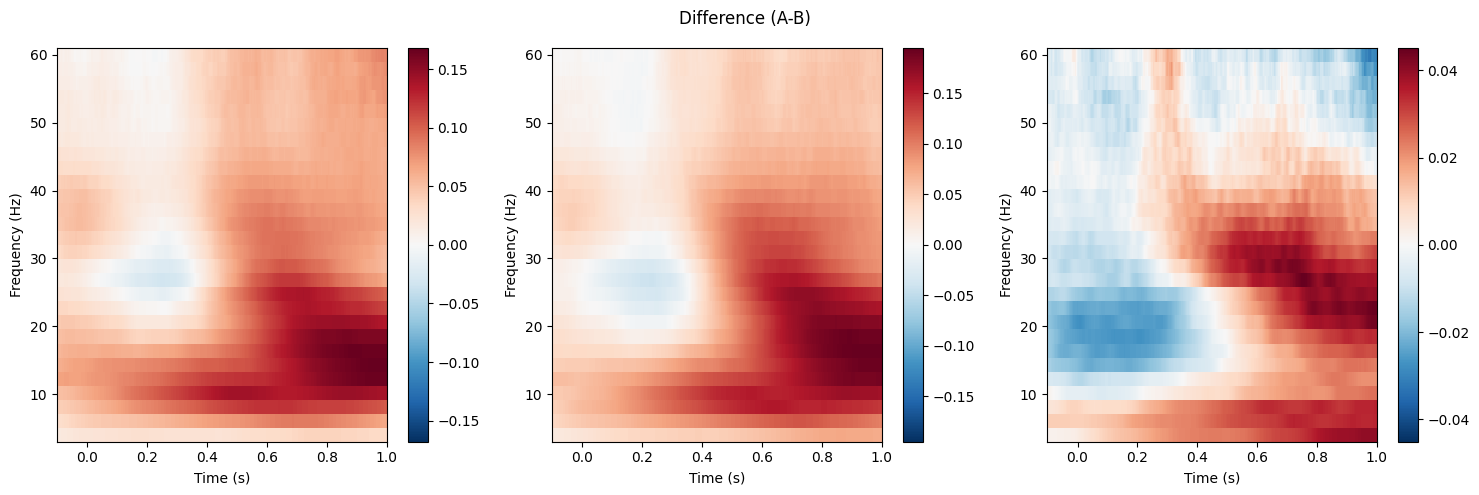

In [82]:
# 1. Create Grand Averages for each condition
ga_cond_a = mne.grand_average([t.copy().apply_baseline((-.4,-.2),'logratio') for t in tfrs[c1]]).crop(-.1,1)
ga_cond_b = mne.grand_average([t.copy().apply_baseline((-.4,-.2),'logratio') for t in tfrs[c2]]).crop(-.1,1)

# 2. Calculate the Difference TFR (A - B)
# Note: Since TFRs are in dB/log, subtraction = ratio comparison
ga_diff = mne.time_frequency.combine_tfr([ga_cond_b,ga_cond_a],[1,-1])

# 3. Plotting side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

roi = ['C4'];roi=None

ga_cond_a.plot(picks=roi, combine='mean', axes=axes[0], title="Condition A", show=False)
ga_cond_b.plot(picks=roi, combine='mean', axes=axes[1], title="Condition B", show=False)
ga_diff.plot(picks=roi, combine='mean', axes=axes[2], title="Difference (A-B)", show=False)

plt.tight_layout()
plt.show()

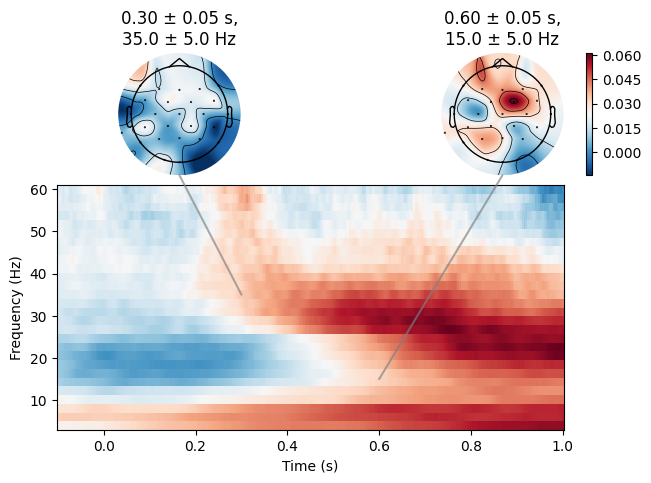

In [83]:
ga_diff.plot_joint(timefreqs={(.3,35):(.1,10),(.6,15):(.1,10)});

In [109]:
# Create a list of "Evoked-like" objects for Alpha power (8-12Hz)
alpha_evokeds = {c:[tfr_to_evk(tfr.copy().apply_baseline((-.6,-.4),'zlogratio'),(8,12)) for tfr in v] for c,v in tfrs.items()}

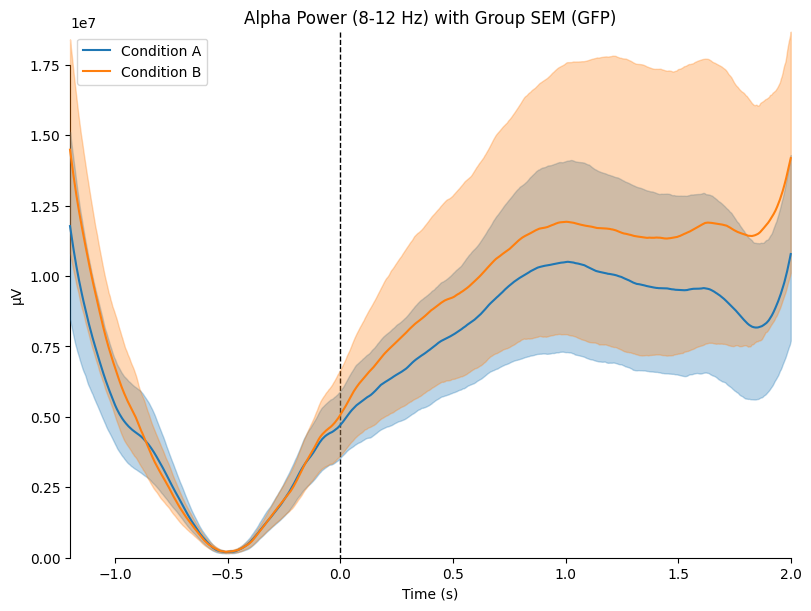

[<Figure size 800x600 with 1 Axes>]

In [110]:
# 3. Now use the high-level group plotter!
mne.viz.plot_compare_evokeds(
    {"Condition A": alpha_evokeds[c1], "Condition B": alpha_evokeds[c2]},
    #picks=[],
    title="Alpha Power (8-12 Hz) with Group SEM"
)

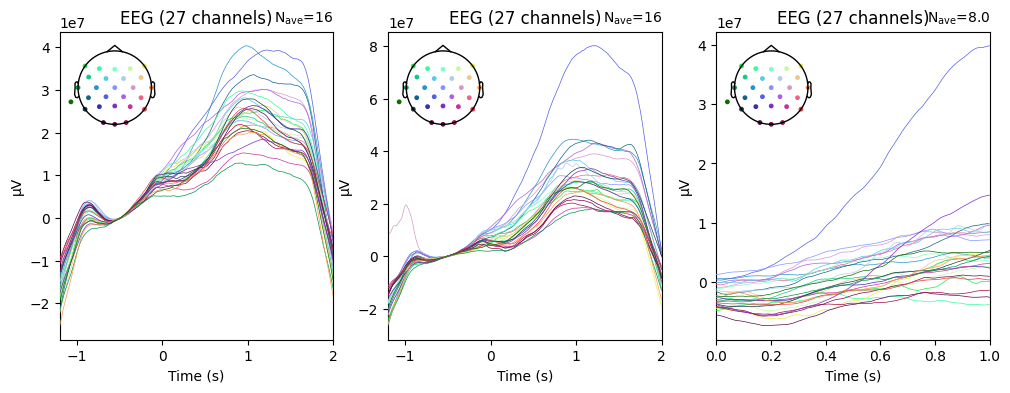

In [108]:
fig,axs = plt.subplots(1,3,figsize=(12,4))
mne.grand_average(alpha_evokeds[c1]).plot(axes=axs[0],show=False);
mne.grand_average(alpha_evokeds[c2]).plot(axes=axs[1],show=False);
mne.combine_evoked([mne.grand_average(alpha_evokeds[c1]),mne.grand_average(alpha_evokeds[c2])],[-1,1]).crop(0,1).plot(axes=axs[2],show=False);

### Annex: 32-channel layout

![](https://www.fieldtriptoolbox.org/assets/img/template/layout/original/dcc_customized_acticap64.png)